In [1]:
# ============================================================
# FINMARK SALES FORECASTING — WEEK 7 HOMEWORK
# Course: MO-IT134 | Section: BSIT-S3101
# Author: Paran, Ralph Matthew
#
# Goal 1: Engineer new features from the cleaned FinMark
#         datasets to enhance sales forecasting performance.
# Goal 2: Build an initial forecasting model using historical
#         data to predict the next 3 months of sales.
#
# Steps:
#   1. Load the preprocessed datasets
#   2. Examine columns and identify feature opportunities
#   3. Engineer and verify new features
#   4. Visualize new features to assess patterns
#   5. Build the forecasting model
#   6. Generate 3-month sales predictions
#   7. Save all outputs
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# set a clean visual style for all charts
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.figsize':   (13, 5),
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [2]:
# ============================================================
# STEP 1 — LOAD THE PREPROCESSED DATASETS
#
# I load the cleaned datasets produced in Weeks 2-3.
# These already have missing values handled and IDs converted,
# so I can move straight into feature engineering.
# ============================================================

import os
os.chdir(r'C:\Users\Matti\Documents\School')

transactions = pd.read_csv('transactions_data_clean.csv')
products     = pd.read_csv('products_data_clean.csv')

print('Datasets loaded!')
print(f'   transactions: {transactions.shape[0]} rows, {transactions.shape[1]} columns')
print(f'   products:     {products.shape[0]} rows, {products.shape[1]} columns')

Datasets loaded!
   transactions: 7277 rows, 7 columns
   products:     18 rows, 3 columns


In [3]:
# ============================================================
# STEP 2 — EXAMINE THE DATASETS
#
# Before engineering features, I examine the available columns
# to understand what data I have and identify opportunities
# to create new, more useful columns for the model.
# ============================================================

for name, df_temp in [('transactions', transactions), ('products', products)]:
    print(f'\n--- {name} ---')
    print('Columns and data types:')
    print(df_temp.dtypes)
    print(f'\nFirst 3 rows:')
    display(df_temp.head(3))


--- transactions ---
Columns and data types:
Transaction_ID        int64
Company_ID            int64
Product_ID            int64
Quantity            float64
Transaction_Date        str
Product_Price       float64
Total_Cost          float64
dtype: object

First 3 rows:


,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price,Total_Cost
0,1,88,6,10.0,2024/03/26,194379.147964,1075200.0
1,2,29,19,16.0,"July 09, 2024",97930.993380,1428000.0
2,4,85,12,12.0,09-06-2023,130556.442432,1008000.0



--- products ---
Columns and data types:
Product_ID       int64
Product_Name       str
Product_Price    int64
dtype: object

First 3 rows:


,Product_ID,Product_Name,Product_Price
0,1,FinPredictor Suite,140000
1,2,MarketMinder Analytics,168000
2,3,TrendWise Forecaster,100800


In [4]:
# ============================================================
# STEP 3 — FEATURE ENGINEERING
#
# Based on my examination, here are all the features I plan
# to generate and why each one helps improve sales prediction:
#
# FEATURE 1: Year
#   Extracted from Transaction_Date.
#   Helps identify long-term growth or decline year over year.
#
# FEATURE 2: Month
#   Extracted from Transaction_Date.
#   Captures seasonal patterns — certain months may have
#   higher sales due to budget cycles or promotions.
#
# FEATURE 3: Quarter
#   Groups months into Q1-Q4.
#   Useful for identifying quarterly sales cycles, which is
#   common in B2B software sales like FinMark.
#
# FEATURE 4: Month_Number (time index)
#   A sequential number representing each month across all years
#   (Jan 2020 = 1, Feb 2020 = 2, Jan 2021 = 13, etc.).
#   This is the primary input for the forecasting model —
#   it gives the model a continuous numeric timeline to learn from.
#
# FEATURE 5: Revenue_Per_Unit
#   Total_Cost divided by Quantity.
#   Measures the average revenue per unit sold.
#   Helps detect pricing changes or product mix shifts over time.
#
# FEATURE 6: Is_High_Value
#   1 if Total_Cost is above the median transaction value, else 0.
#   Flags high-value transactions so patterns in premium
#   purchases can be identified separately.
#
# FEATURE 7: Product_Name
#   Merged from products_data using Product_ID.
#   Allows sales to be broken down and visualized by product.
# ============================================================

# parse the mixed-format dates
transactions['Transaction_Date'] = pd.to_datetime(
    transactions['Transaction_Date'], format='mixed', dayfirst=False
)

df = transactions.copy()

# Feature 1: Year
df['Year'] = df['Transaction_Date'].dt.year

# Feature 2: Month
df['Month'] = df['Transaction_Date'].dt.month

# Feature 3: Quarter
df['Quarter']       = df['Transaction_Date'].dt.quarter
df['Quarter_Label'] = 'Q' + df['Quarter'].astype(str)

# Feature 4: Month_Number (sequential time index starting from 1)
min_year  = df['Year'].min()
min_month = df[df['Year'] == min_year]['Month'].min()
df['Month_Number'] = (df['Year'] - min_year) * 12 + (df['Month'] - min_month + 1)

# Feature 5: Revenue_Per_Unit (avoid division by zero)
df['Revenue_Per_Unit'] = df.apply(
    lambda r: r['Total_Cost'] / r['Quantity'] if r['Quantity'] > 0 else 0, axis=1
)

# Feature 6: Is_High_Value
median_cost = df['Total_Cost'].median()
df['Is_High_Value'] = (df['Total_Cost'] > median_cost).astype(int)

# Feature 7: Product_Name (merge from products)
df = df.merge(products[['Product_ID','Product_Name']], on='Product_ID', how='left')
df['Product_Name'] = df['Product_Name'].fillna('Unknown')

print('All 7 features engineered successfully!')
print(f'Dataset now has {df.shape[1]} columns.')
print(f'Date range: {df["Transaction_Date"].min().date()} to {df["Transaction_Date"].max().date()}')

All 7 features engineered successfully!
Dataset now has 15 columns.
Date range: 2020-01-11 to 2024-12-10


In [5]:
# ============================================================
# STEP 3 (continued) — VERIFY ENGINEERED FEATURES
#
# I check that all new columns were computed correctly by
# reviewing their summary statistics and value ranges.
# ============================================================

print('Sample of engineered features (first 5 rows):')
display(df[['Transaction_Date','Year','Month','Quarter_Label',
            'Month_Number','Revenue_Per_Unit','Is_High_Value','Product_Name']].head())

print('\nSummary statistics:')
print(df[['Year','Month','Quarter','Month_Number',
          'Revenue_Per_Unit','Is_High_Value']].describe().round(2).to_string())

print(f'\nYear range:         {df["Year"].min()} to {df["Year"].max()}')
print(f'Month range:        {df["Month"].min()} to {df["Month"].max()}')
print(f'Quarter values:     {sorted(df["Quarter_Label"].unique())}')
print(f'Month_Number range: {df["Month_Number"].min()} to {df["Month_Number"].max()}')
print(f'Is_High_Value:      {df["Is_High_Value"].value_counts().to_dict()}')
print(f'Unique products:    {df["Product_Name"].nunique()}')
print(f'Missing values:     {df.isnull().sum().sum()}')

Sample of engineered features (first 5 rows):


,Transaction_Date,Year,Month,Quarter_Label,Month_Number,Revenue_Per_Unit,Is_High_Value,Product_Name
0,2024-03-26,2024,3,Q1,51,107520.0,0,RevenueVue Dashboard
1,2024-07-09,2024,7,Q3,55,89250.0,1,EcoNomix Modeler
2,2023-09-06,2023,9,Q3,45,84000.0,0,BudgetMaster Pro
3,2021-07-06,2021,7,Q3,19,88200.0,0,TrendWise Forecaster
4,2021-07-12,2021,7,Q3,19,156800.0,0,OptiFlow Automation



Summary statistics:
          Year    Month  Quarter  Month_Number  Revenue_Per_Unit  Is_High_Value
count  7277.00  7277.00  7277.00       7277.00           7277.00        7277.00
mean   2022.34     6.47     2.50         34.50         143177.95           0.44
std       1.16     3.42     1.11         13.79          98223.51           0.50
min    2020.00     1.00     1.00          1.00              0.00           0.00
25%    2021.00     4.00     2.00         23.00          96000.00           0.00
50%    2022.00     6.00     2.00         35.00         130666.67           0.00
75%    2023.00     9.00     3.00         46.00         168000.00           1.00
max    2024.00    12.00     4.00         60.00        1344000.00           1.00

Year range:         2020 to 2024
Month range:        1 to 12
Quarter values:     ['Q1', 'Q2', 'Q3', 'Q4']
Month_Number range: 1 to 60
Is_High_Value:      {0: 4106, 1: 3171}
Unique products:    19
Missing values:     0


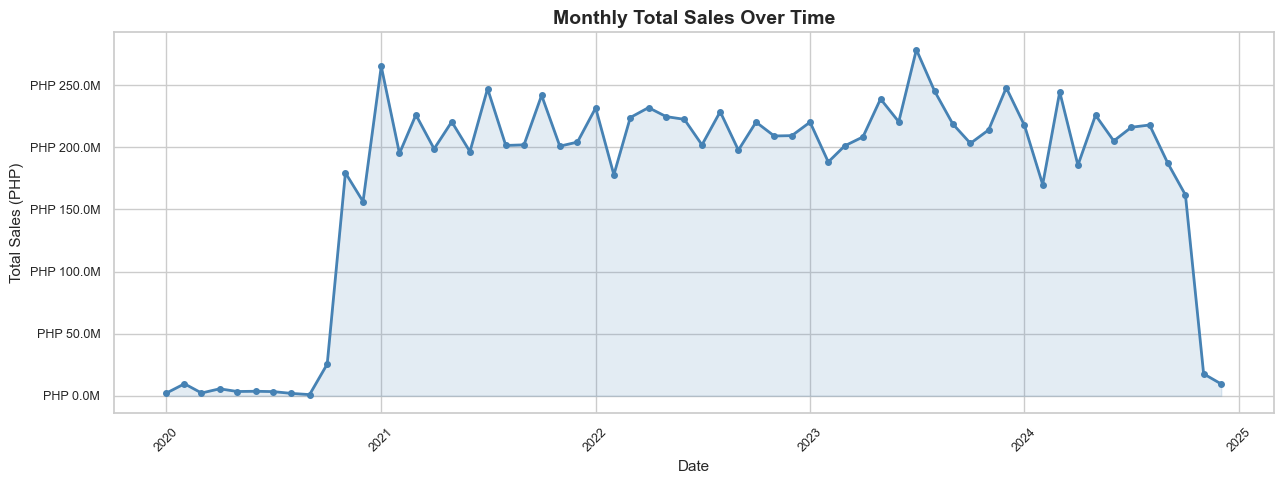

Chart 1 saved.


In [6]:
# ============================================================
# STEP 4 — VISUALIZE NEW FEATURES
#
# I create charts to explore patterns in the engineered features
# and assess their relationship to sales trends.
# ============================================================

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# --- CHART 1: Monthly Total Sales Over Time (Line Chart) ---
# Shows the overall sales trend across the full date range.
# Helps identify whether sales are growing, declining, or flat.

monthly_sales = df.groupby(['Year','Month'])['Total_Cost'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year','Month']].assign(day=1))
monthly_sales = monthly_sales.sort_values('Date')

fig, ax = plt.subplots()
ax.fill_between(monthly_sales['Date'], monthly_sales['Total_Cost'],
                alpha=0.15, color='steelblue')
ax.plot(monthly_sales['Date'], monthly_sales['Total_Cost'],
        color='steelblue', linewidth=2, marker='o', markersize=4,
        label='Monthly Sales')
ax.set_title('Monthly Total Sales Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e6:.1f}M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart1_monthly_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved.')

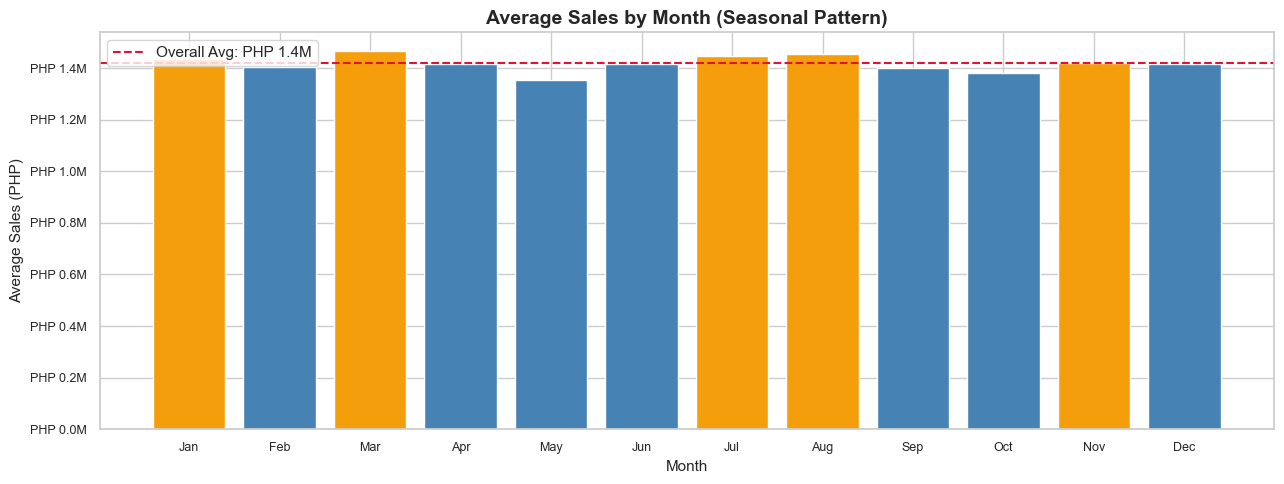

Chart 2 saved.


In [7]:
# --- CHART 2: Average Sales by Month (Seasonal Pattern) ---
# Shows which months consistently have higher or lower sales.
# This reveals seasonal patterns — useful for forecasting.

avg_by_month = df.groupby('Month')['Total_Cost'].mean().reset_index()
avg_by_month['Month_Name'] = avg_by_month['Month'].apply(lambda x: month_names[x-1])
overall_avg  = avg_by_month['Total_Cost'].mean()
bar_colors   = ['#F59E0B' if v >= overall_avg else 'steelblue'
                for v in avg_by_month['Total_Cost']]

fig, ax = plt.subplots()
ax.bar(avg_by_month['Month_Name'], avg_by_month['Total_Cost'],
       color=bar_colors, edgecolor='white')
ax.axhline(overall_avg, color='crimson', linestyle='--',
           linewidth=1.5, label=f'Overall Avg: PHP {overall_avg/1e6:.1f}M')
ax.set_title('Average Sales by Month (Seasonal Pattern)')
ax.set_xlabel('Month')
ax.set_ylabel('Average Sales (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e6:.1f}M'))
ax.legend()
plt.tight_layout()
plt.savefig('chart2_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved.')

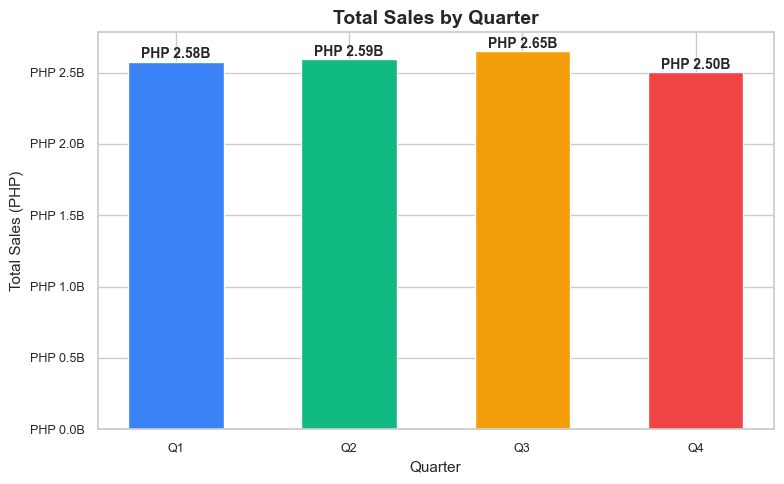

Chart 3 saved.


In [8]:
# --- CHART 3: Total Sales by Quarter ---
# Shows which quarter drives the most revenue.

quarterly = df.groupby('Quarter_Label')['Total_Cost'].sum().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(quarterly['Quarter_Label'], quarterly['Total_Cost'],
              color=['#3B82F6','#10B981','#F59E0B','#EF4444'],
              edgecolor='white', width=0.55)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5e6,
            f'PHP {bar.get_height()/1e9:.2f}B',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Total Sales by Quarter')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Sales (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e9:.1f}B'))
plt.tight_layout()
plt.savefig('chart3_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved.')

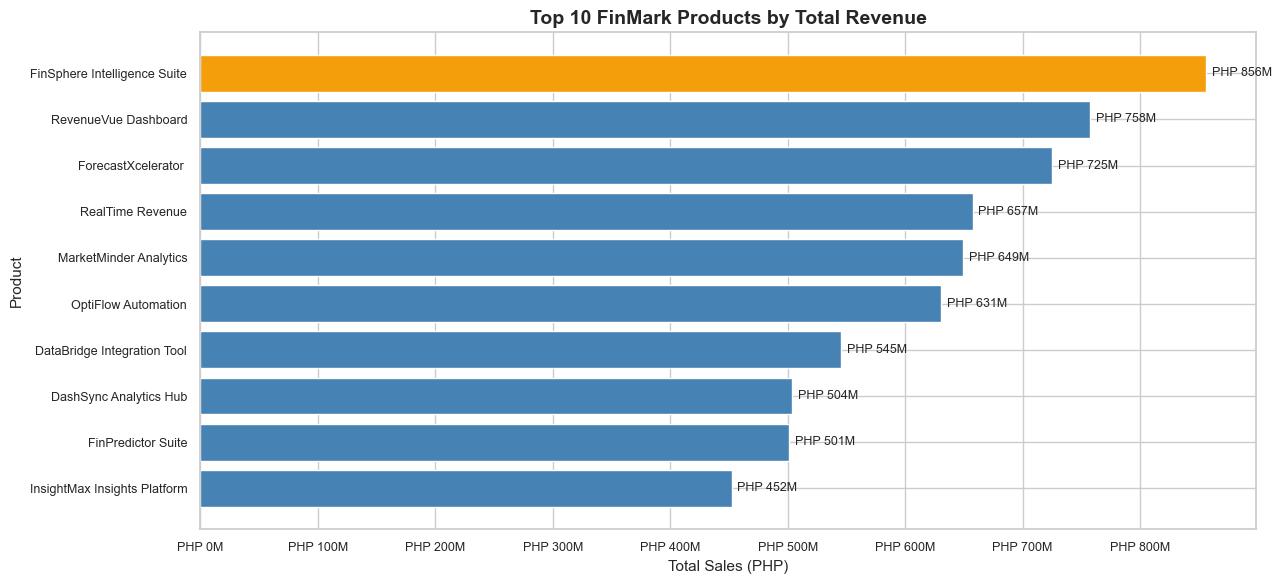

Chart 4 saved.


In [9]:
# --- CHART 4: Top 10 Products by Total Sales ---
# Ranks the top revenue-generating FinMark products.

product_sales = (df[df['Product_Name'] != 'Unknown']
                 .groupby('Product_Name')['Total_Cost']
                 .sum().sort_values(ascending=True).tail(10))
bar_colors = ['#F59E0B' if i == len(product_sales)-1 else 'steelblue'
              for i in range(len(product_sales))]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(product_sales.index, product_sales.values,
               color=bar_colors, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 5e6, bar.get_y() + bar.get_height()/2,
            f'PHP {bar.get_width()/1e6:.0f}M', va='center', fontsize=9)
ax.set_title('Top 10 FinMark Products by Total Revenue')
ax.set_xlabel('Total Sales (PHP)')
ax.set_ylabel('Product')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e6:.0f}M'))
plt.tight_layout()
plt.savefig('chart4_products.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved.')

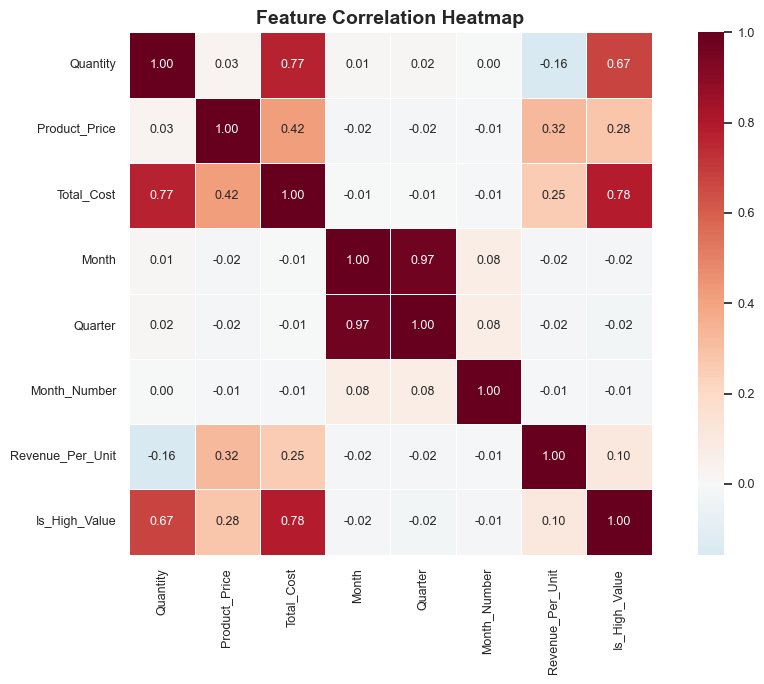

Chart 5 saved.


In [10]:
# --- CHART 5: Correlation Heatmap ---
# Shows how strongly each numeric feature correlates with Total_Cost.
# Features with high correlation are most useful for predicting sales.

corr_cols = ['Quantity','Product_Price','Total_Cost',
             'Month','Quarter','Month_Number',
             'Revenue_Per_Unit','Is_High_Value']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True,
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('chart5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5 saved.')

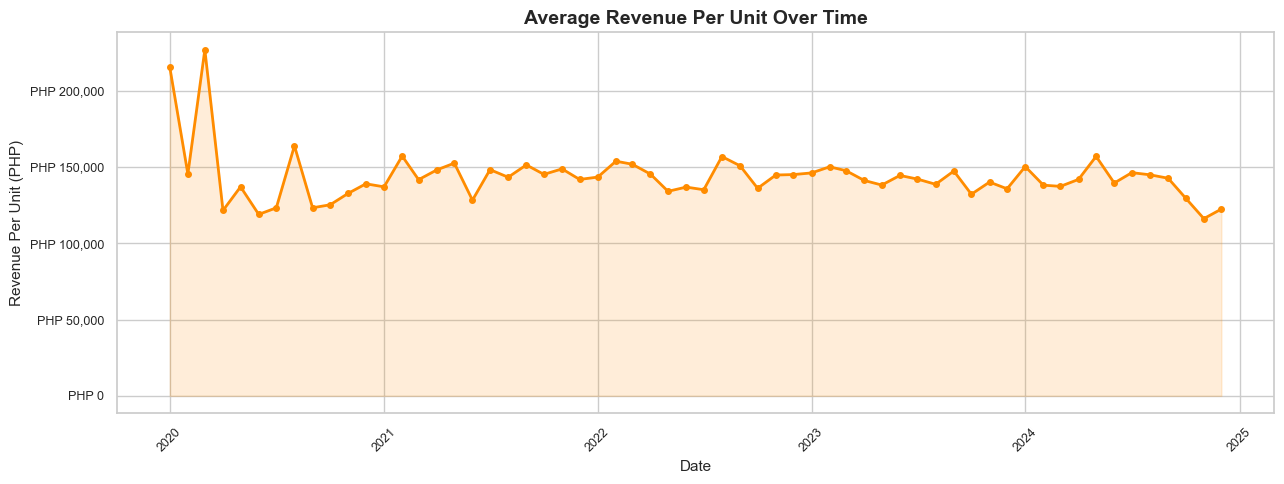

Chart 6 saved.


In [11]:
# --- CHART 6: Revenue Per Unit Over Time ---
# Shows whether average revenue per unit is changing over time.
# A declining trend could signal pricing pressure or product mix shifts.

rpu_monthly = df.groupby(['Year','Month'])['Revenue_Per_Unit'].mean().reset_index()
rpu_monthly['Date'] = pd.to_datetime(rpu_monthly[['Year','Month']].assign(day=1))
rpu_monthly = rpu_monthly.sort_values('Date')

fig, ax = plt.subplots()
ax.fill_between(rpu_monthly['Date'], rpu_monthly['Revenue_Per_Unit'],
                alpha=0.15, color='darkorange')
ax.plot(rpu_monthly['Date'], rpu_monthly['Revenue_Per_Unit'],
        color='darkorange', linewidth=2, marker='o', markersize=4)
ax.set_title('Average Revenue Per Unit Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue Per Unit (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart6_revenue_per_unit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6 saved.')

In [12]:
# ============================================================
# STEP 5 — BUILD THE FORECASTING MODEL
#
# I aggregate total sales per month to create a time series,
# then use Linear Regression to model the trend over time.
#
# Why Linear Regression?
#   - Simple and interpretable
#   - Works well when there is a consistent trend in the data
#   - Month_Number gives it a clean numeric timeline to learn from
#   - Introduced as a forecasting tool in this course
#
# Input (X):  Month_Number — the sequential time index
# Output (y): Total monthly sales
# ============================================================

# aggregate total sales per month
monthly = df.groupby('Month_Number').agg(
    Total_Sales = ('Total_Cost', 'sum'),
    Year        = ('Year',       'first'),
    Month       = ('Month',      'first')
).reset_index().sort_values('Month_Number')

monthly['Date'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))

# train the model
X = monthly[['Month_Number']].values
y = monthly['Total_Sales'].values

model = LinearRegression()
model.fit(X, y)
y_fitted = model.predict(X)

# evaluate
mae  = mean_absolute_error(y, y_fitted)
rmse = np.sqrt(mean_squared_error(y, y_fitted))
r2   = r2_score(y, y_fitted)

print(f'Model trained on {len(monthly)} months of data')
print(f'\nModel Evaluation:')
print(f'   R² Score : {r2:.4f}  (how well the trend fits the data)')
print(f'   MAE      : PHP {mae:>15,.0f}  (average monthly prediction error)')
print(f'   RMSE     : PHP {rmse:>15,.0f}  (error penalizing large misses more)')
print(f'\nTrend: monthly sales change by PHP {model.coef_[0]:,.0f} per month')

Model trained on 60 months of data

Model Evaluation:
   R² Score : 0.2090  (how well the trend fits the data)
   MAE      : PHP      59,638,259  (average monthly prediction error)
   RMSE     : PHP      75,903,600  (error penalizing large misses more)

Trend: monthly sales change by PHP 2,252,599 per month


In [13]:
# ============================================================
# STEP 6 — GENERATE 3-MONTH SALES PREDICTIONS
#
# I extend the Month_Number sequence by 3 to represent the
# next 3 months after the last date in the dataset.
# The model uses the learned trend to predict each month.
# ============================================================

FORECAST_MONTHS = 3

last_month_number = monthly['Month_Number'].max()
last_year         = monthly[monthly['Month_Number'] == last_month_number]['Year'].values[0]
last_month        = monthly[monthly['Month_Number'] == last_month_number]['Month'].values[0]

# build future month numbers and calendar labels
future_month_numbers = [last_month_number + i for i in range(1, FORECAST_MONTHS + 1)]
future_dates, future_labels = [], []

for i in range(1, FORECAST_MONTHS + 1):
    fm = (last_month + i - 1) % 12 + 1
    fy = last_year + (last_month + i - 1) // 12
    future_dates.append(pd.Timestamp(year=fy, month=fm, day=1))
    future_labels.append(f'{month_names[fm-1]} {fy}')

# generate predictions
future_X           = np.array(future_month_numbers).reshape(-1, 1)
future_predictions = model.predict(future_X)

# display forecast table
forecast_df = pd.DataFrame({
    'Month':           future_labels,
    'Predicted_Sales': future_predictions.round(0)
})

print('3-Month Sales Forecast:')
print('=' * 45)
for _, row in forecast_df.iterrows():
    print(f"  {row['Month']:12s}  PHP {row['Predicted_Sales']:>18,.0f}")
print('=' * 45)
print(f'  Total (3 months)  PHP {future_predictions.sum():>18,.0f}')

3-Month Sales Forecast:
  Jan 2025      PHP        240,684,754
  Feb 2025      PHP        242,937,353
  Mar 2025      PHP        245,189,952
  Total (3 months)  PHP        728,812,059


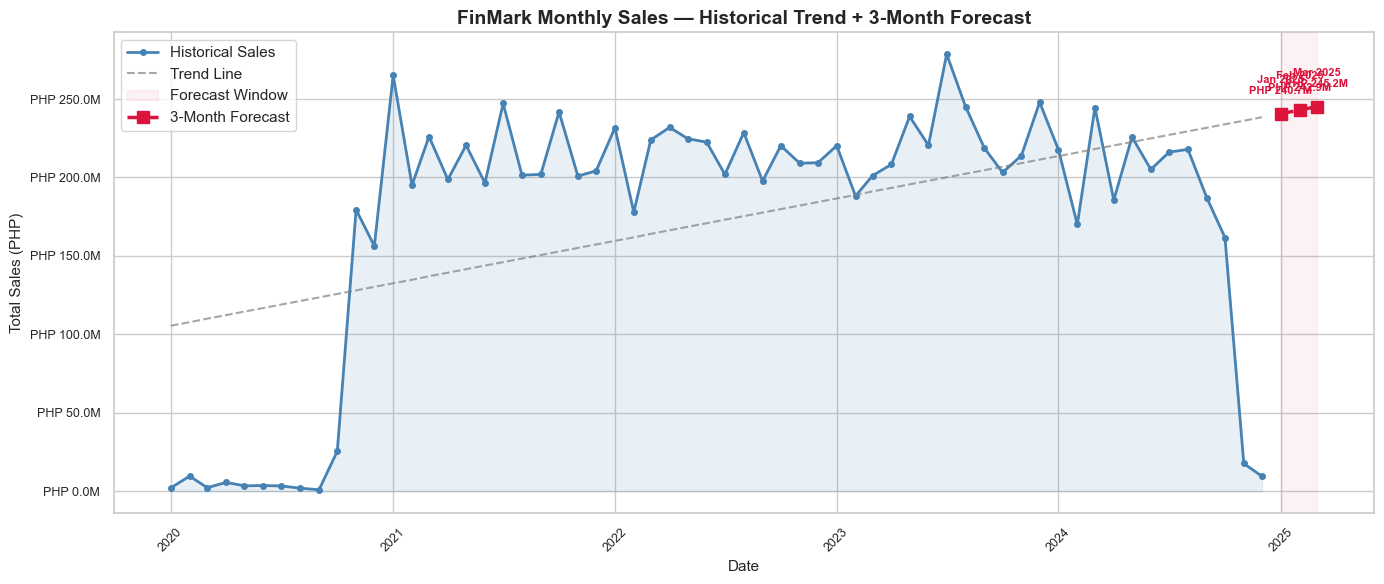

Chart 7 saved.


In [14]:
# --- CHART 7: Historical Sales + 3-Month Forecast ---
# Shows the full historical trend alongside the 3-month prediction.
# The shaded red zone highlights the forecast window.

fig, ax = plt.subplots(figsize=(14, 6))

# historical
ax.fill_between(monthly['Date'], monthly['Total_Sales'],
                alpha=0.12, color='steelblue')
ax.plot(monthly['Date'], monthly['Total_Sales'],
        color='steelblue', linewidth=2, marker='o', markersize=4,
        label='Historical Sales')
ax.plot(monthly['Date'], y_fitted,
        color='gray', linewidth=1.5, linestyle='--', alpha=0.7,
        label='Trend Line')

# forecast
ax.axvspan(future_dates[0], future_dates[-1],
           alpha=0.06, color='crimson', label='Forecast Window')
ax.plot(future_dates, future_predictions,
        color='crimson', linewidth=2.5, linestyle='--',
        marker='s', markersize=9, label='3-Month Forecast')

# value labels on forecast points
for date, val, label in zip(future_dates, future_predictions, future_labels):
    ax.annotate(f'{label}\nPHP {val/1e6:.1f}M',
                xy=(date, val), xytext=(0, 14),
                textcoords='offset points', ha='center',
                fontsize=8, color='crimson', fontweight='bold')

ax.set_title('FinMark Monthly Sales — Historical Trend + 3-Month Forecast')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e6:.1f}M'))
ax.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart7_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 7 saved.')

In [15]:
# ============================================================
# STEP 7 — SAVE ALL OUTPUTS
# ============================================================

# save updated dataset with engineered features
df.to_csv('transactions_featured.csv', index=False)

# save the 3-month forecast
forecast_df.to_csv('finmark_3month_forecast.csv', index=False)

print('All outputs saved to C:\\Users\\Matti\\Documents\\School')
print('')
print('Files saved:')
print('   transactions_featured.csv    <- dataset with engineered features')
print('   finmark_3month_forecast.csv  <- 3-month sales forecast')
print('   chart1_monthly_sales.png     <- monthly sales over time')
print('   chart2_seasonal.png          <- seasonal pattern by month')
print('   chart3_quarterly.png         <- sales by quarter')
print('   chart4_products.png          <- top 10 products by revenue')
print('   chart5_heatmap.png           <- feature correlation heatmap')
print('   chart6_revenue_per_unit.png  <- revenue per unit over time')
print('   chart7_forecast.png          <- historical + 3-month forecast')

All outputs saved to C:\Users\Matti\Documents\School

Files saved:
   transactions_featured.csv    <- dataset with engineered features
   finmark_3month_forecast.csv  <- 3-month sales forecast
   chart1_monthly_sales.png     <- monthly sales over time
   chart2_seasonal.png          <- seasonal pattern by month
   chart3_quarterly.png         <- sales by quarter
   chart4_products.png          <- top 10 products by revenue
   chart5_heatmap.png           <- feature correlation heatmap
   chart6_revenue_per_unit.png  <- revenue per unit over time
   chart7_forecast.png          <- historical + 3-month forecast
